In [1]:
# 환경 설정 및 라이브러리 설치
!pip install -q openai langchain langchain-openai langchain-community faiss-cpu \
    rank_bm25 pandas numpy matplotlib gradio python-dotenv tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [3]:
!pip install langgraph

In [6]:
import os, json, math
from datetime import datetime, timedelta
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional, TypedDict, Annotated, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from dotenv import load_dotenv
# load_dotenv()
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
MODEL = "gpt-4o-mini"

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool, StructuredTool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage

import os, json, time, hmac, hashlib, requests
#from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool, StructuredTool
from langchain_core.messages import HumanMessage, ToolMessage
# LangGraph
from langgraph.graph import StateGraph, START, END

from pydantic import BaseModel, Field
#load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini")

In [5]:
import os
from typing import TypedDict, Annotated, Optional
from dotenv import load_dotenv
load_dotenv()
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

llm = ChatOpenAI(model="gpt-4o-mini")

## LangGraph

In [ ]:
# 랭체인의 경우
# chain = prompt | retriever | llm | parser
# 직선으로 대화 경로가 이어짐

# 하지만 실사용 시, 답변 경로가 여러 갈래(분기)로 이어지거나, 답변 품질에 따라 순환 경로(loop) 등이 필요할 수 있음.

In [ ]:
# LangGraph
# 구성요소
  # node : 함수(search, find, ...)
  # edge: node 들을 연결하는 선 (e.g., A 노드가 끝나면 B 노드로 이동해라 등)
  # state: 그래프 전체에서 공유하는 dictionary

# 예) 삼성역, 강남역 등 -> 노드
  # 이어주는 선로 -> 엣지

In [4]:
# 랭체인이랑 어떤 점이 구별될까?
# 랭체인
from langchain_core.runnables import RunnableLambda

chain = RunnableLambda(lambda x : x.upper()) | RunnableLambda(lambda x : x + "!") # 하나는 대문자, 하나는 느낌표 달아주는 러너블
print(chain.invoke('hello')) # 결과는 대문자 + "!""

HELLO!


### 그래프 만들기 1

In [10]:
class MiniState(TypedDict): # TypedDict는 꼭 필요한건 아니지만, 코딩하기 편하려고 사용(변수명, 타입 등 점검 용이)
  text : str

def upper_node(state):
  return {'text': state['text'].upper()} # state(텍스트)를 받아서 upper, 즉 대문자로 바꿔준다.

def excite_node(state):
  return {'text': state['text']+ "!"}

# StateGraph
b = StateGraph(MiniState) # state를 안에 넣어서 초기화

# 만들었던 노드들이, 그래프에 해당된다는 의미로 등록
b.add_node('upper', upper_node) # 이름 및 함수명을 차례대로 작성
b.add_node('excite', excite_node)

# 다음은 엣지를 만들어야함.
  # start와 end 필요
b.add_edge(START, 'upper') # 그래프 시작(Start)에서 나와서 'upper'라는 노드로 이동
b.add_edge('upper', 'excite')
b.add_edge('excite', END) # 그래프의 끝(END)
app = b.compile() # 컴파일(compile)이란 그래프를 실행 가능한 객체로 만드는 것 (컴파일은 한번만 일어남)
app.invoke({'text': 'hello'})
# hello -> "HELLO!"

{'text': 'HELLO!'}

In [ ]:
# 리마인드
# 노드는 함수!
# State 정의 -> node 함수들 정의 -> 그래프 조립 -> 컴파일

### 그래프 만들기 2

In [12]:
class SimpleState(TypedDict):
  message : str

def greet(state: SimpleState) -> dict:
  return {'message' : f"안녕, {state['message']}"}

builder = StateGraph(SimpleState)
builder.add_node('greet', greet) # 앞은 노드 이름, 뒤는 노드 함수명

builder.add_edge(START, 'greet') # START - greet - END 간의 엣지
builder.add_edge('greet', END)

app = builder.compile()
app.invoke({'message': '월요일'})

{'message': '안녕, 월요일'}

실습

In [15]:
# name 키를 받아서 '안녕하세요, {name}님!' 을 리턴

class SampleState(TypedDict):
  name : str

def hello_name(state: SampleState) -> dict:
  return {'name' : f"안녕하세요, {state['name']}님!"}

bb = StateGraph(SampleState)
bb.add_node('name', hello_name) # 앞은 노드 이름, 뒤는 노드 함수명

bb.add_edge(START, 'name') # START - name - END 간의 엣지
bb.add_edge('name', END)

aa = bb.compile()
aa.invoke({'name': '권중석'})

{'name': '안녕하세요, 권중석님!'}

### State
- State 부터 자세히 다룰 예정
- State 설계가 Graph에서 많은 부분을 차지함(70% 이상?)
- Graph 전체에서 공유하는 데이터 딕셔너리
- TypedDict를 쓰는 이유는, 노드들이 어떤 데이터를 쓰고 읽을지 미리 알려주는 용도

In [16]:
class ChatState(TypedDict): # state 1
  user_msg : str # 메시지
  reply : str # 답변
  turn : int # 몇턴 째 답변인지

class AnalysisState(TypedDict): # state 2
  text : str
  word_count : int
  sentiment : str

b1 = StateGraph(ChatState)
b2 = StateGraph(AnalysisState)
type(b1).__name__, type(b2).__name__

('StateGraph', 'StateGraph')

In [17]:
class UserState(TypedDict): # 다양한 키(변수)를 이용해서 그래프에서 사용되는 state를 만들어 줄 수 있음
  user_id : str
  name : str
  age : int
  is_active : bool

b1 = StateGraph(UserState)
UserState.__annotations__

{'user_id': str, 'name': str, 'age': int, 'is_active': bool}

### Node 함수
- 변경된 키(변수)만 리턴되도록 해야함.

In [20]:
class CounterState(TypedDict):
  count: int
  note : str

def add_one(state : CounterState) -> dict: # state : {'count' : 1, 'note' : 'abc'}
  return {'count' : state['count'] + 1}

b = StateGraph(CounterState)
b.add_node('add_one', add_one)
b.add_edge(START, 'add_one')
b.add_edge('add_one', END)

b.compile().invoke({'count': 0, 'note': "안녕하세요"})

{'count': 1, 'note': '안녕하세요'}

In [22]:
# ScoreState를 작성하여 그래프를 만들어 업데이트
  # score에 10을 더해 갱신하는 스테이트
class ScoreState(TypedDict):
  name: int
  score : str
  bonus : int

def bump_score(state : ScoreState) -> dict:
  return {'score' : state['score'] + 10}

# 만약 이런식으로 하면?
# def bump_score(state : ScoreState) -> dict:
#   state['score'] + 10
#   return state      # state 전체를 반환 {'name' : 이름, 'score' : 이전 스코어 ...}
  # 이러면 동작은 하지만 그래프가 커질 때 문제가 생길 수 있음

b = StateGraph(ScoreState)
b.add_node('bump_score', bump_score)
b.add_node('bump_score_2', bump_score)

b.add_edge(START, 'bump_score')
b.add_edge('bump_score', 'bump_score_2')
b.add_edge('bump_score', END)

b.compile().invoke({'score': 0})

{'score': 20}

### Multi-node serial

In [26]:
class TextState(TypedDict):
  text : str
  upper : str
  length : int

def to_upper(state: TextState) -> dict:
  return {'upper': state['text'].upper()}

def measure(state: TextState) -> dict:
  return {'length' : len(state['text'])}

builder = StateGraph(TextState)
builder.add_node('to_upper', to_upper)
builder.add_node('measure', measure)

builder.add_edge(START, 'to_upper')
builder.add_edge('to_upper', 'measure')
builder.add_edge('measure', END)

app = builder.compile()

app.invoke({'text': 'hello langgraph', 'upper' : '', 'length' : 0 })

{'text': 'hello langgraph', 'upper': 'HELLO LANGGRAPH', 'length': 15}

In [27]:
# DocState
# raw
# cleaned # 공백 제거
# tranlated # 대문자로 변환
# summary  # [:5]

class DocState(TypedDict):
  raw : str
  cleaned: str
  translated : str
  summary : str
  # log를 남기고 싶을때..
  # log : str

def clean_raw(state: DocState) -> dict:
  return {'cleaned': state['raw'].strip()} # log 예시: 'log': state['log'] + 'clean'

def translate(state: DocState) -> dict:
  return {'translated': state['cleaned'].upper()} # log 예시: 'log': state['log'] + 'translate'

def summarize(state: DocState) -> dict:
  return {'summary': state['translated'][:5]} # log 예시: 'log': state['log'] + 'summary'

b = StateGraph(DocState)

# [팁]: 노드가 많다면, for문으로 넣을 수 있음
# for n, fn in [('cleaned', clean_raw), ('translated', translate) ...]:
#     builder.add_node(n, fn)

b.add_node('cleaned', clean_raw)
b.add_node('translated', translate)
b.add_node('summary', summarize)

b.add_edge(START, 'cleaned')
b.add_edge('cleaned', 'translated')
b.add_edge('translated', 'summary')
b.add_edge('summary', END)

a = b.compile()
a.invoke({"raw": "  hello langgraph world  ", "cleaned": "", "translated": "", "summary": ""})

# log 출력 결과 (근데, 자체 함수도 있는 듯 함)
# : 'log': clean, translate, summary ... 등  -> 실행 순서를 시각화 가능

{'raw': '  hello langgraph world  ',
 'cleaned': 'hello langgraph world',
 'translated': 'HELLO LANGGRAPH WORLD',
 'summary': 'HELLO'}

In [ ]:
{"raw": "  hello langgraph world  ", "cleaned": "", "translated": "", "summary": ""}

### LLM을 붙이는 단계
- LangGraph + LLM, 결과 확인

In [29]:
class QAState(TypedDict):
  question : str
  answer : str

def llm_answer(state: QAState) -> dict:
  response = llm.invoke([HumanMessage(content = state['question'])]) # question이 들어와서 answer를 업데이트
  return {'answer' : response.content}

builder = StateGraph(QAState)
builder.add_node('llm_answer', llm_answer)
builder.add_edge(START, 'llm_answer')
builder.add_edge('llm_answer', END)
app = builder.compile()
app.invoke({'question' : 'langgraph를 한 문장으로?', 'answer' : ''})

{'question': 'langgraph를 한 문장으로?',
 'answer': 'LangGraph는 자연어 처리와 그래프 데이터베이스의 융합을 통해 언어와 지식을 구조적으로 연결하고 시각화하는 플랫폼입니다.'}

In [30]:
# 두개의 키값 이용하여 translate
class TransState(TypedDict):
  ko : str
  en : str

def translate(state :TransState):
  response = llm.invoke([HumanMessage(content = f"다음 한국어 문장을 영어로 번역해주세요: {state['ko']}")]) # question이 들어와서 answer를 업데이트
  return {'en' : response.content}

builder = StateGraph(TransState)
builder.add_node('translate', translate)

builder.add_edge(START, 'translate')
builder.add_edge('translate', END)
app = builder.compile()


app.invoke({"ko": "오늘 날씨가 좋네요.", "en": ""})

{'ko': '오늘 날씨가 좋네요.', 'en': 'The weather is nice today.'}

In [34]:
# 강사님 코드
class TransState(TypedDict):
  ko : str
  en : str

def translate(state :TransState):
  response = llm.invoke([
      SystemMessage(content = 'translate to english'),
      HumanMessage(content = state['ko']})
      ]) # question이 들어와서 answer를 업데이트
  return {'en' : response.content}

builder = StateGraph(TransState)
builder.add_node('translate', translate)
builder.add_edge(START, 'translate')
builder.add_edge('translate', END)
app = builder.compile()

app.invoke({"ko": "오늘 날씨가 좋네요.", "en": ""})

{'ko': '오늘 날씨가 좋네요.', 'en': 'The weather is nice today.\n'}

### LangGraph 조금 더 심화

In [39]:
class NumberState(TypedDict): # 어떤 숫자를 입력받아 짝수/홀수 분기에 따라 다르게 리턴
  n : int
  label : str

def start_n(state):
  return {}

def even_handler(state):
  return {'label' : f"{state['n']}은(는) 짝수입니다."}

def odd_handler(state):
  return {'label' : f"{state['n']}은(는) 홀수입니다."}

def parity_router(state) ->str:
# 조건문을 사용하기도 하는데..
# if state['n'] == 1:
#    return 'odd1' ..
# 위와 같이 할거면 키를 누락하지 말아야 함.
  return 'even' if state['n']%2 == 0 else 'odd' # 짝수 또는 홀수 판별

b = StateGraph(NumberState)
b.add_node('start_n', start_n)
b.add_node('even_handler', even_handler)
b.add_node('odd_handler', odd_handler)

b.add_edge(START, 'start_n') # 아래에 'start_n' 자리에 바로 START를 안쓰는 이유는 'add_conditional_edges'의 시작(이전노드)이 항상 노드여야 하기 때문
b.add_conditional_edges('start_n', parity_router, {'even': 'even_handler', 'odd' : 'odd_handler'}) # 라우터로 보내줌 (분기문)
b.add_edge('even_handler', END)

b.add_edge('odd_handler', END)
app = b.compile()
app.invoke({'n' : 5})

{'n': 5, 'label': '5은(는) 홀수입니다.'}

In [ ]:
# ExamState : score(int), result(str)

# score >= 60 : pass

# 미만 : fail

# pass_node : 합격입니다.
# fail_node: 불합격입니다.

# START -> start_n -> condition -> pass/fail node


# 테스트
# print(app.invoke({"score": 85, "result": ""}))
# print(app.invoke({"score": 40, "result": ""}))

In [40]:
# ExamState : score(int), result(str)
# score >= 60 : pass
# pass_node : 합격입니다.
# fail_node: 불합격입니다.
# START -> start_n -> condition -> pass/fail node

class ExamState(TypedDict):
    score: int
    result: str

def start_n(state):
    return {}

def pass_node(state):
    return {'result': f"{state['score']}점, 합격입니다."}

def fail_node(state):
    return {'result': f"{state['score']}점, 불합격입니다."}

def pass_router(state) -> str:
    # score가 60 이상이면 pass, 미만이면 fail
    return 'pass' if state['score'] >= 60 else 'fail'

b = StateGraph(ExamState)
b.add_node('start_n', start_n)
b.add_node('pass_node', pass_node)
b.add_node('fail_node', fail_node)

b.add_edge(START, 'start_n')
b.add_conditional_edges('start_n', pass_router, {'pass': 'pass_node', 'fail': 'fail_node'})
b.add_edge('pass_node', END)
b.add_edge('fail_node', END)

app = b.compile()

# 테스트
print(app.invoke({"score": 85, "result": ""}))
print(app.invoke({"score": 40, "result": ""}))

{'score': 85, 'result': '85점, 합격입니다.'}
{'score': 40, 'result': '40점, 불합격입니다.'}


In [42]:
class GradeState(TypedDict):
  score : int
  grade : str

def start_grade(state) : return {}

def grade_a(state): return {'grade' : 'A'} # prefix로 '입니다' 등을 붙이려면..?
def grade_b(state): return {'grade' : 'B'}  # 분기가 끝난 이후 동일하게 적용되어야 할 경우
def grade_c(state): return {'grade' : 'C'}

def grade_router(state) -> str:
  if state['score'] >= 90: return 'a'
  if state['score'] >= 79: return 'b'
  return 'c'

b = StateGraph(GradeState)
b.add_node('start_grade', start_grade)
b.add_node('grade_a', grade_a)
b.add_node('grade_b', grade_b)
b.add_node('grade_c', grade_c)

b.add_edge(START, 'start_grade')
b.add_conditional_edges('start_grade', grade_router,
                      {'a': 'grade_a',
                        'b': 'grade_b',
                        'c': 'grade_c'})

for n in ['grade_a', 'grade_b', 'grade_c']:
  b.add_edge(n, END)

app = b.compile()


In [45]:
# 분기가 끝난 이후 동일하게 적용되어야 할 경우
class QuestionState(TypedDict):
  question: str
  qtype : str
  answer : str


def h_when(state):
  return {'answer' : '[시간] 답변'}
def h_where(state):
  return {'answer' : '[장소] 답변'}
def h_what(state):
  return {'answer' : '[일반] 답변'}
def h_stmt(state):
  return {'answer' : '[진술문] 답변'}

def merge(state):
  return {'answer' : state['answer'] + '!!!!!'}

def classify(state):
  q = state['question'].lower()
  if '?' not in q: return {'qtype' : 'statement'}
  if any(w in q for w in ['언제', 'when']): return {'qtype': 'when'}
  if any(w in q for w in ['어디', 'where']): return {'qtype': 'where'}
  return {'qtype' : 'what'}

In [50]:
b = StateGraph(QuestionState)
b.add_node('classify', classify)
for name, fn in [('h_when', h_when), ('h_where', h_where), ('h_what', h_what), ('h_stmt', h_stmt)]:
  b.add_node(name, fn)

b.add_node('merge', merge)

b.add_edge(START, 'classify')
b.add_conditional_edges('classify', lambda s: s['qtype'],
                        {'when' : 'h_when','where' : 'h_where', 'what':'h_what', 'statement':'h_stmt'  })

b.add_edge('h_when', 'merge')
b.add_edge('h_where', 'merge')
b.add_edge('h_what', 'merge')
b.add_edge('h_stmt', 'merge')

b.add_edge('merge', END)

app = b.compile()
app.invoke({'question' : "회의 어디서 해?"})

{'question': '회의 어디서 해?', 'qtype': 'where', 'answer': '[장소] 답변!!!!!'}

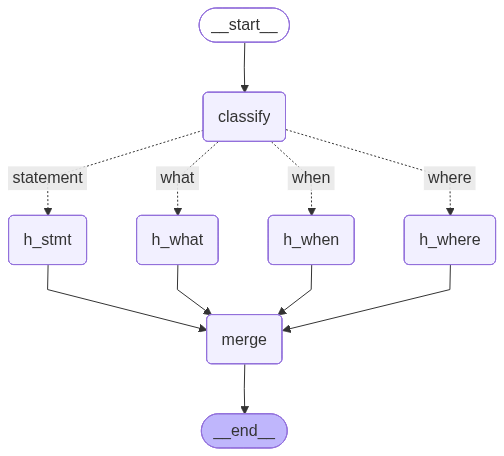

In [47]:
app # 분기가 어디이든 항상 merge를 통과후 답변을 준다..